# Experimentos con Datos con Desgaste sin Realizar Segmentación
#### Estudiantes: Matías Carvajal y Daryl Clerc
#### Profesores: Pablo Estévez, Jorge Vergara
#### EL7037 - Primavera 2025

## Librerías y Funciones

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np
import sympy as sp

In [18]:
from sklearn.metrics import mean_squared_error

def eval_equations(x, y, equations):
    """
    Evalúa una lista de expresiones matemáticas contra los datos y calcula el MSE para cada una.

    :param x: dataframe con las variables
    :param y: variable objetivo
    :param equations: dataframe/lista con las expresiones obtenidas
    :return: lista de tuplas (expresión, MSE) ordenadas de menor a mayor MSE.
    """
    resultados = []

    for eq in equations:
        try:
            float(eq)
            resultados.append(np.inf)
        except ValueError:
            y_pred = eval(eq, {"__builtins__": {}, "np": np, 'log': np.log, 'exp': np.exp}, x.to_dict(orient='series'))
            mse = mean_squared_error(y, y_pred)
            resultados.append(mse)

    return pd.DataFrame({'expresiones': equations, 'mse': resultados})

In [3]:
def get_general_metrics(y_pred, y_true):
    """
    Calcula las métricas de error RMSE, MAE y SMAPE, junto con su desviación estándar.
    :param y_pred: Arreglo con los valores predichos por la ecuación obtenida.
    :param y_true: Arreglo con los valores reales de la variable.
    :return: Retorna un diccionario, donde los values son una tupla con el valor de la métrica
             y la desviación estándar; y las keys son los strings de las métricas calculadas
             i.e. 'RMSE', 'MAE, 'SMAPE'.
    """

    # Cálculo de errores
    errores_rmse = (y_true - y_pred) ** 2
    errores_mae = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2 + 1e-6
    errores_smape = (np.abs(y_true - y_pred) / denominator) * 100

    # Cálculo de métricas
    rmse = np.round(np.sqrt(np.mean(errores_rmse)), 2)
    mae = np.round(np.mean(errores_mae), 2)
    smape = np.round(np.mean(errores_smape), 2)

    # Cálculo de desviaciones estándar
    std_rmse = np.round(np.std(np.sqrt(errores_rmse)), 2)
    std_mae = np.round(np.std(errores_mae), 2)
    std_smape = np.round(np.std(errores_smape), 2)

    # Retorna un diccionario con las métricas y sus desviaciones estándar
    return {
        "RMSE": (float(rmse), float(std_rmse)),
        "MAE": (float(mae), float(std_mae)),
        "SMAPE": (float(smape), float(std_smape))
    }

## Número de Nusselt

### Base de datos y Exploración

In [4]:
x_train = pd.read_csv(r'.\DATA_LIB_Degradation\df_n_train_des.txt')
y_train = x_train['nusselt']
x_train = x_train.drop('nusselt', axis=1)
print('x_train:')
display(x_train.head())
print('y_train:', y_train.to_numpy()[: 5])

x_train:


,S,Re,Pr,SoH
0,0.280625,212.041256,0.709840,0.6363
1,0.280625,212.041256,0.707471,1.0000
2,0.280625,197.894331,0.706170,1.0000
3,0.344410,188.969448,0.708576,0.6363
4,0.344410,188.969448,0.704657,1.0000


y_train: [12.63272114 13.64363625 14.81134875 11.75386263 12.61276223]


In [5]:
x_val = pd.read_csv(r'.\DATA_LIB_Degradation\df_n_val_des.txt')
y_val = x_val['nusselt']
x_val = x_val.drop('nusselt', axis=1)
x_val

,S,Re,Pr,SoH
0,1.038156,745.465433,0.710556,0.8181
1,1.038156,745.465433,0.710200,0.8181
2,1.038156,692.028356,0.709984,1.0000
3,1.038156,680.067627,0.709899,1.0000
4,1.038156,655.436666,0.709738,1.0000
...,...,...,...,...
15728,0.911669,818.127652,0.706280,1.0000
15729,0.911669,751.097192,0.706263,1.0000
15730,0.911669,747.250023,0.706245,1.0000
15731,0.911669,711.906739,0.706225,0.4545


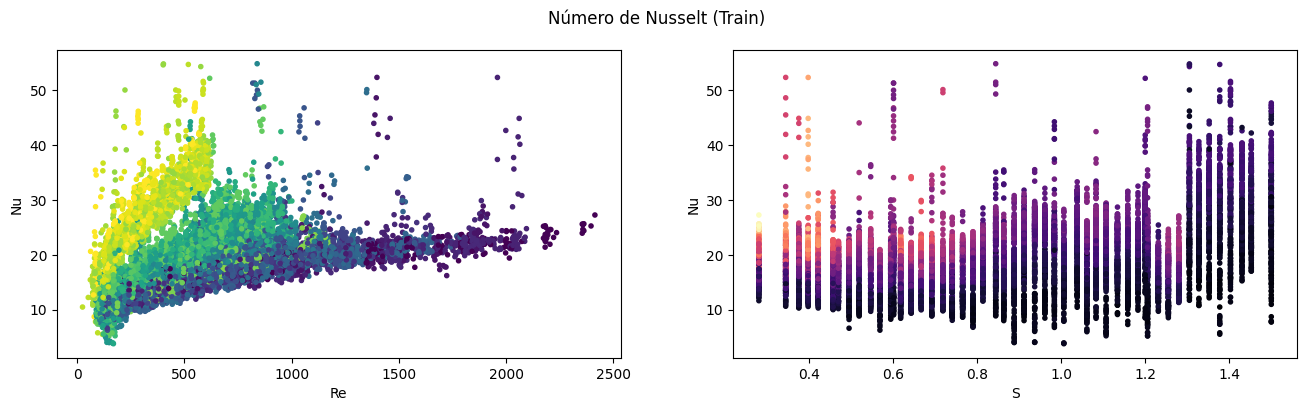

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4))

ax[0].scatter(x_train['Re'], y_train, marker='.', c=x_train['S'])
ax[0].set_xlabel('Re')
ax[0].set_ylabel('Nu')

ax[1].scatter(x_train['S'], y_train, marker='.', c=x_train['Re'], cmap='magma')
ax[1].set_xlabel('S')
ax[1].set_ylabel('Nu')

fig.suptitle('Número de Nusselt (Train)')
plt.show()

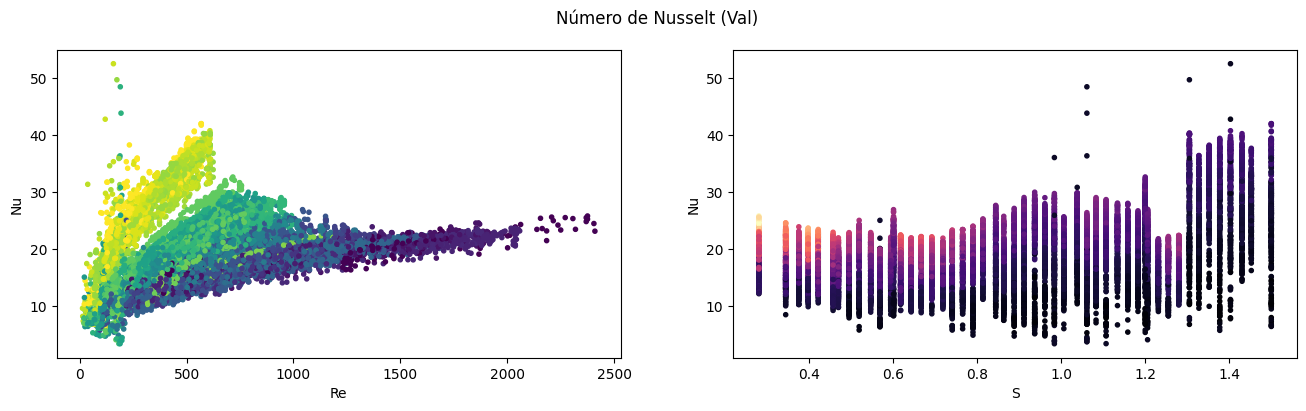

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4))

ax[0].scatter(x_val['Re'], y_val, marker='.', c=x_val['S'])
ax[0].set_xlabel('Re')
ax[0].set_ylabel('Nu')

ax[1].scatter(x_val['S'], y_val, marker='.', c=x_val['Re'], cmap='magma')
ax[1].set_xlabel('S')
ax[1].set_ylabel('Nu')

fig.suptitle('Número de Nusselt (Val)')
plt.show()

In [83]:
print(len(np.unique(x_train['S'])))

50


### Segmentación con DB-Scan

In [33]:
x_min, x_max = x_train.min(), x_train.max()
xn_train = (x_train - x_min) / (x_max - x_min)
xn_train.head()

,S,Re,Pr,SoH
0,0.000000,0.078191,0.949814,0.333272
1,0.000000,0.078191,0.818411,1.000000
2,0.000000,0.072269,0.746265,1.000000
3,0.052307,0.068533,0.879694,0.333272
4,0.052307,0.068533,0.662373,1.000000


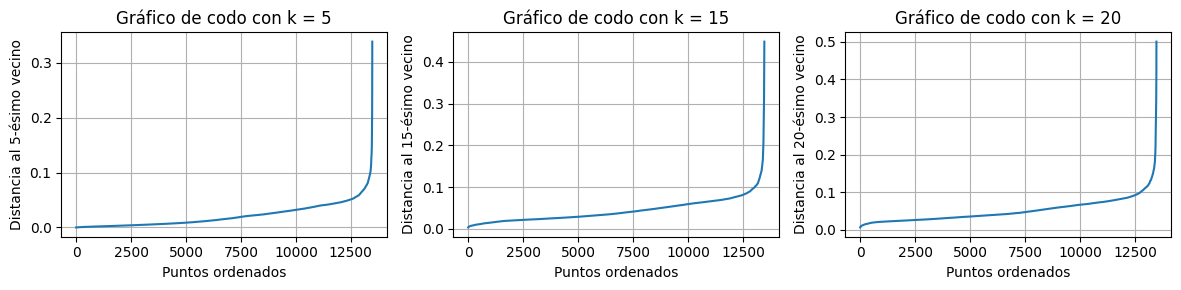

In [34]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

fig, ax = plt.subplots(1, 3, figsize=(12, 3))

k = 5  # usado como min_samples en DBSCAN
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(xn_train)
distances, _ = neighbors_fit.kneighbors(xn_train)
k_distances = np.sort(distances[:, k - 1])  # Ordenar las distancias al k-ésimo vecino

ax[0].plot(k_distances)
ax[0].set_ylabel(f'Distancia al {k}-ésimo vecino')
ax[0].set_xlabel('Puntos ordenados')
ax[0].set_title(f'Gráfico de codo con k = {k}')
ax[0].grid(True)

k = 15  # usado como min_samples en DBSCAN
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(xn_train)
distances, _ = neighbors_fit.kneighbors(xn_train)
k_distances = np.sort(distances[:, k - 1])  # Ordenar las distancias al k-ésimo vecino

ax[1].plot(k_distances)
ax[1].set_ylabel(f'Distancia al {k}-ésimo vecino')
ax[1].set_xlabel('Puntos ordenados')
ax[1].set_title(f'Gráfico de codo con k = {k}')
ax[1].grid(True)

k = 20  # usado como min_samples en DBSCAN
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(xn_train)
distances, _ = neighbors_fit.kneighbors(xn_train)
k_distances = np.sort(distances[:, k - 1])  # Ordenar las distancias al k-ésimo vecino

ax[2].plot(k_distances)
ax[2].set_ylabel(f'Distancia al {k}-ésimo vecino')
ax[2].set_xlabel('Puntos ordenados')
ax[2].set_title(f'Gráfico de codo con k = {k}')
ax[2].grid(True)

plt.tight_layout()
plt.show()

In [43]:
from sklearn.cluster import DBSCAN

clustering = DBSCAN(eps=0.24).fit(x_train)
clusters = clustering.labels_
print('clusters =', np.unique(clusters).shape[0])
print(np.unique(clusters, return_counts=True))

clusters = 508
(array([ -1,   0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,
        12,  13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,
        25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,
        38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,
        51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,
        64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,
        77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,
        90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102,
       103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115,
       116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128,
       129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141,
       142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154,
       155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167,
       168, 169, 170, 171, 172, 173, 174, 175, 1

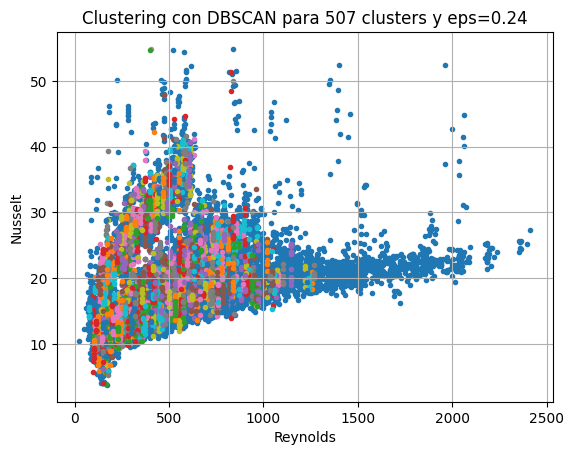

In [45]:
# Graficar cada cluster por separado
for i in np.unique(clusters):
    idx = clusters == i
    label = f'Cluster {i + 1}'
    plt.scatter(x_train['Re'][idx], y_train[idx], marker='.', label=label)

plt.grid()
plt.ylabel('Nusselt')
plt.xlabel('Reynolds')
plt.title(f'Clustering con DBSCAN para {np.unique(clusters).shape[0] - 1} clusters y eps=0.24')
plt.show()

### Segmentación con Arboles

In [87]:
from sklearn.tree import DecisionTreeRegressor

reg = DecisionTreeRegressor(
    max_depth=2,
    min_samples_leaf=2500,
    random_state=42
)
reg.fit(x_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,2500
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


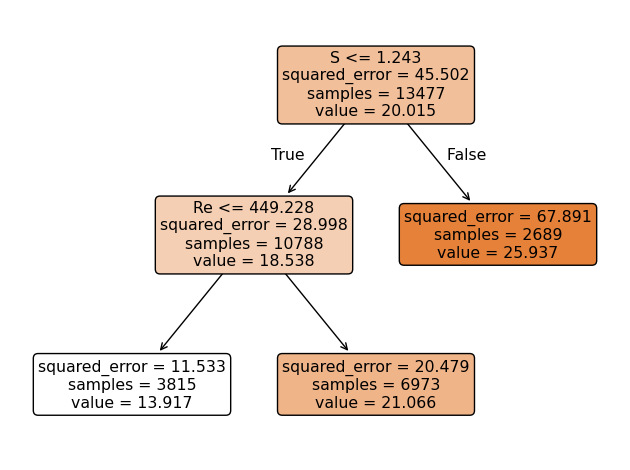

In [88]:
from sklearn.tree import plot_tree

plot_tree(
    reg,
    feature_names=x_train.columns,
    filled=True,
    rounded=True
)
plt.tight_layout()
plt.show()

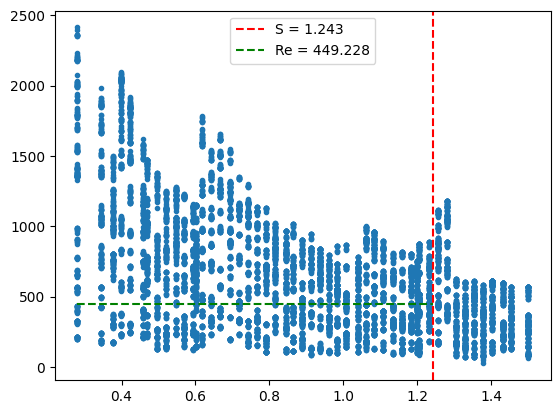

In [89]:
plt.scatter(x_train['S'], x_train['Re'], marker='.')
plt.axvline(x=1.243, color='red', linestyle='--', label='S = 1.243')
plt.plot([x_train['S'].min(), 1.243], [449.228, 449.228], color='green', linestyle='--', label='Re = 449.228')
plt.legend()
plt.show()

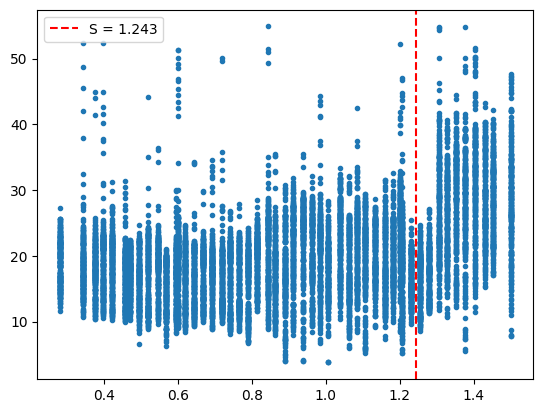

In [90]:
plt.plot(x_train['S'], y_train, '.')
plt.axvline(x=1.243, color='red', linestyle='--', label='S = 1.243')
plt.legend()
plt.show()

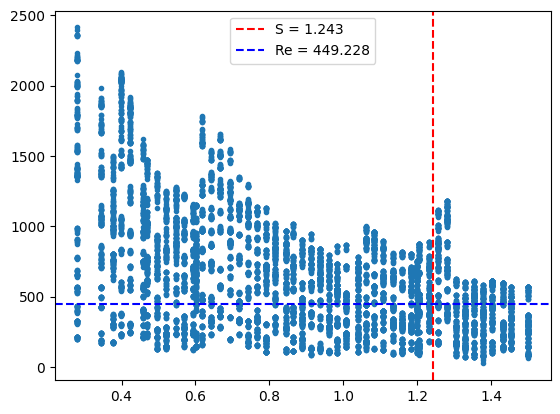

In [91]:
plt.scatter(x_train['S'], x_train['Re'], marker='.')
plt.axvline(x=1.243, color='red', linestyle='--', label='S = 1.243')
plt.axhline(y=449.228, color='blue', linestyle='--', label='Re = 449.228')
plt.legend()
plt.show()

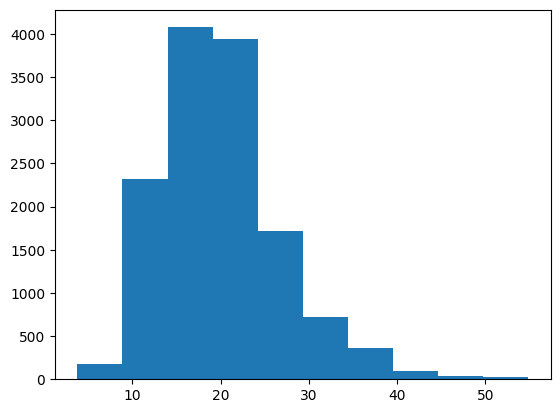

20.01450210170413 +/- 6.74553197442427


In [92]:
plt.hist(y_train)
plt.show()
print(np.mean(y_train), '+/-', np.std(y_train))

### Segmentación con otras formas de Clustering

In [93]:
from sklearn import mixture

gmm = mixture.GaussianMixture(
        n_components=3,
        covariance_type="full",
        random_state=42,
    )

gmm.fit(xn_train)
clusters = gmm.predict(xn_train)
print('clusters =', np.unique(clusters, return_counts=True))

clusters = (array([0, 1, 2]), array([5248, 4499, 3730]))


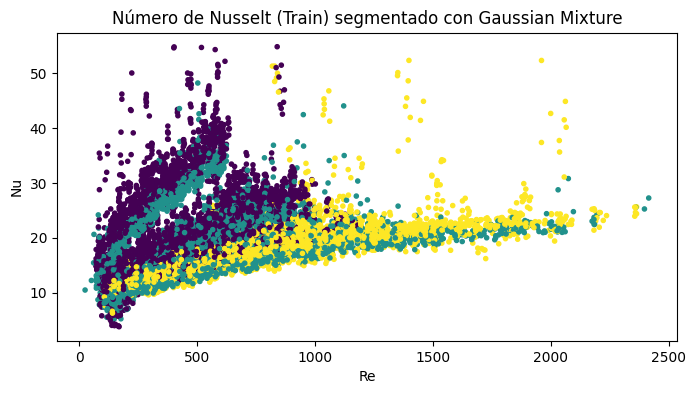

In [94]:
plt.figure(figsize=(8, 4))
plt.scatter(x_train['Re'], y_train, marker='.', c=clusters)
plt.title('Número de Nusselt (Train) segmentado con Gaussian Mixture')
plt.xlabel('Re')
plt.ylabel('Nu')
plt.show()

In [95]:
from sklearn import cluster

hdbscan = cluster.HDBSCAN(
    min_samples=20,
    min_cluster_size=15,
    allow_single_cluster=True,
)

hdbscan.fit(xn_train)
clusters = hdbscan.labels_.astype(int)
print('clusters =', np.unique(clusters, return_counts=True))

clusters = (array([-1,  0,  1,  2,  3]), array([  15, 8975, 1495, 1495, 1497]))


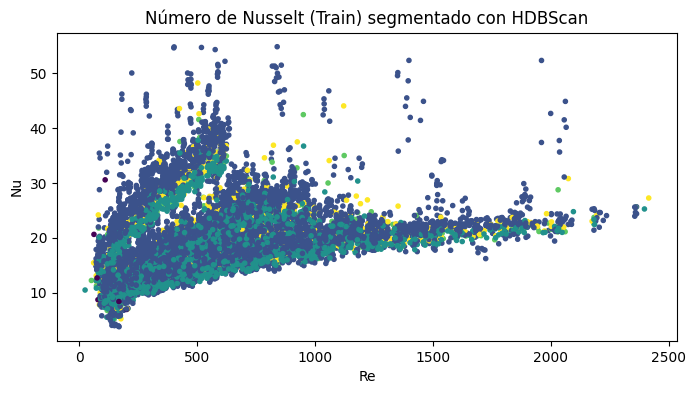

In [96]:
plt.figure(figsize=(8, 4))
plt.scatter(x_train['Re'], y_train, marker='.', c=clusters)
plt.title('Número de Nusselt (Train) segmentado con HDBScan')
plt.xlabel('Re')
plt.ylabel('Nu')
plt.show()

### Evolución Grámatica (sin segmentación)

In [97]:
from time import time
from tqdm import tqdm

from pysr import PySRRegressor

In [124]:
x_train.rename(columns={'S': 'Se'}, inplace=True)

model = PySRRegressor(
    niterations=200,
    binary_operators=["+","-","*" ,"/", "^"],
    unary_operators=[],
    population_size=50,
    populations=4,
    tournament_selection_n=3,
    verbosity=1,
    maxsize=20,
    parsimony=1e-2,
    constraints={'^':(-1,1)},
    complexity_of_variables=2,
    random_state=0,
    progress=True
)

t0 = time()
model.fit(x_train, y_train)
tf = time()

print(f"Tiempo de ejecución: {tf - t0} [s]")

C:\Users\matia\PycharmProjects\GE_Re_EL7037_2025\.venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
C:\Users\matia\PycharmProjects\GE_Re_EL7037_2025\.venv\Lib\site-packages\pysr\sr.py:2265: UserWarning: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (https://ai.damtp.cam.ac.uk/pysr/options/#batching). You should also reconsider if you need that many datapoints. Unless you have a large amount of noise (in which case you should smooth your dataset first), generally < 10,000 datapoints is enough to find a functional form with symbolic regression. More datapoints will lower the search speed.
  warnings.warn(
C:\Users\matia\PycharmProjects\GE_Re_EL7037_2025\.venv\Lib\site-packages\pysr\sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic 


Expressions evaluated per second: 3.570e+04
Progress: 28 / 800 total iterations (3.500%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.550e+01  0.000e+00  y = 20.014
4           4.373e+01  1.328e-02  y = Se - -19.136
6           4.310e+01  7.215e-03  y = (Se / 0.63556) - -19.136
7           4.294e+01  3.756e-03  y = 19.999 + (Se * Se)
8           3.779e+01  1.278e-01  y = ((Se + 1.1503) / 0.12772) - -3.86
10          3.441e+01  4.676e-02  y = (((Se ^ 4.7925) * 0.59752) + 5.6107) * 3.083
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 4.680e+

[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 1.560e+04
Progress: 648 / 800 total iterations (81.000%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.550e+01  0.000e+00  y = 20.014
4           4.372e+01  1.328e-02  y = Se + 19.115
6           3.431e+01  1.212e-01  y = (Se ^ 6.4745) - -17.79
8           3.430e+01  1.976e-04  y = ((Se ^ 5.8008) - -14.67) ^ 1.0677
9           2.462e+01  3.317e-01  y = (Re ^ 0.38629) - (Se * -9.897)
11          1.954e+01  1.155e-01  y = ((Se / 0.64579) ^ 3.4606) + (Re ^ 0.43081)
13          1.952e+01  5.043e-04  y = (((Se / 0.64579) ^ 3.4606) + (Re ^ 0.43081)) + -0.4404...
                                      7
16          1.917e+01  5.972e-03  y = (((Se / 0.64468) ^ 3.4382) + ((Re ^ 0.42946) + SoH)) -...
                                       0.98302
18     

In [125]:
equations = model.equations_['equation']
equations = equations.apply(lambda x: x.replace('^', '**'))
print('=== TRAIN ===')
df_train = eval_equations(x_train, y_train, equations).sort_values(by='mse')
display(df_train)

print('\n=== VALIDATION ===')
x_val.rename(columns={'S': 'Se'}, inplace=True)
df_val = eval_equations(x_val, y_val, equations).sort_values(by='mse')
display(df_val)

=== TRAIN ===


,expresiones,mse
9,(((((Se / 0.65151566) ** 3.4939196) + SoH) + (...,18.933336
8,(Re ** 0.4293992) + ((((Se / 0.65776443) ** 3....,19.135727
7,((Re ** 0.4293992) + ((Se / 0.65776443) ** 3.5...,19.172071
6,(Re ** 0.4308128) + (((Se / 0.6457888) ** 3.46...,19.340530
5,((Se / 0.65776443) ** 3.5318732) + (Re ** 0.42...,19.482801
4,(Se + 0.4308128) * (Re ** 0.4308128),24.574717
3,((Se ** 5.8007617) - -14.66982) ** 1.0676985,34.300932
2,(Se ** 6.474474) - -17.790165,34.314619
1,Se + 19.114872,43.724883
0,20.014498,inf



=== VALIDATION ===


,expresiones,mse
9,(((((Se / 0.65151566) ** 3.4939196) + SoH) + (...,14.451003
7,((Re ** 0.4293992) + ((Se / 0.65776443) ** 3.5...,14.617449
8,(Re ** 0.4293992) + ((((Se / 0.65776443) ** 3....,14.620487
6,(Re ** 0.4308128) + (((Se / 0.6457888) ** 3.46...,14.681742
5,((Se / 0.65776443) ** 3.5318732) + (Re ** 0.42...,14.847457
4,(Se + 0.4308128) * (Re ** 0.4308128),18.862718
3,((Se ** 5.8007617) - -14.66982) ** 1.0676985,30.103484
2,(Se ** 6.474474) - -17.790165,30.158986
1,Se + 19.114872,39.760662
0,20.014498,inf


In [126]:
expr = sp.sympify(
    df_val['expresiones'].iloc[0]
).evalf(4)
expr

Re**0.4302 + 4.468*Se**3.494 + 2.0*SoH - 1.886

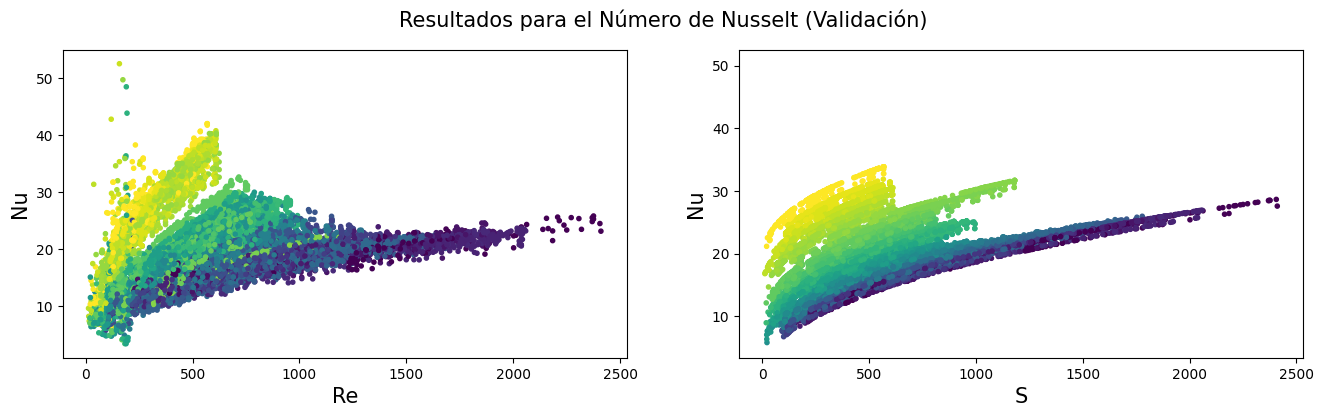

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4))

x = x_val
y = y_val

ax[0].scatter(x['Re'], y, marker='.', c=x['S'])
ax[0].set_xlabel('Re', fontsize=15)
ax[0].set_ylabel('Nu', fontsize=15)

y_pred = x['Re'] ** 0.4302 + 4.468 * x['S'] ** 3.494 + 2 * x['SoH'] - 1.886
ax[1].scatter(x['Re'], y_pred, marker='.', c=x['S'])
ax[1].set_xlabel('S', fontsize=15)
ax[1].set_ylabel('Nu', fontsize=15)
ax[1].set_ylim([y.min(), y.max()])

fig.suptitle('Resultados para el Número de Nusselt (Validación)', fontsize=15)
plt.show()

In [127]:
x_test = pd.read_csv(r'.\DATA_LIB_Degradation\df_n_test_des.txt')
y_true = x_test['nusselt']
x_test = x_test.drop('nusselt', axis=1)
print('x_test:')
display(x_train.head())
print('y_test:', y_true.to_numpy()[: 5])

f = sp.lambdify(sp.symbols('Re SoH Se Pr'), expr, 'numpy')
y_pred = f(x_test['Re'].to_numpy(),
           x_test['SoH'].to_numpy(),
           x_test['S'].to_numpy(),
           x_test['Pr'].to_numpy())
print('y_pred =', y_pred[: 5])
print('n_pred =', len(y_pred), '/ n_true =', len(y_true))
print()

results = get_general_metrics(y_pred, y_true)
for key, value in results.items():
    print(key, '=', value[0], '+/-', value[1])

x_test:


,Se,Re,Pr,SoH
0,0.280625,212.041256,0.709840,0.6363
1,0.280625,212.041256,0.707471,1.0000
2,0.280625,197.894331,0.706170,1.0000
3,0.344410,188.969448,0.708576,0.6363
4,0.344410,188.969448,0.704657,1.0000


y_test: [12.65606225 13.78598212 14.02560596 13.66040888 13.68752691]
y_pred = [ 9.4319976  10.1593976   9.84172623  9.63591486  9.54533879]
n_pred = 15731 / n_true = 15731

RMSE = 3.78 +/- 2.57
MAE = 2.78 +/- 2.57
SMAPE = 14.11 +/- 12.93


### Segmentación con $\log(S)$

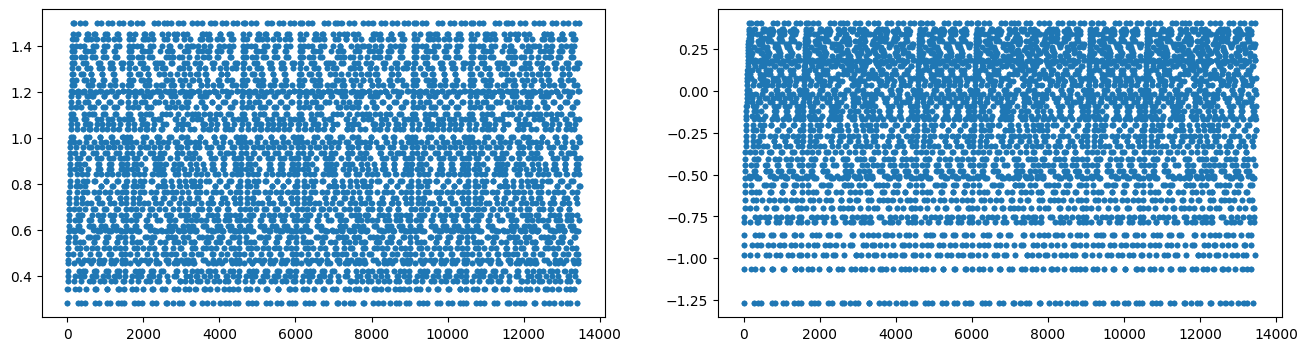

,S,Re,Pr,SoH
0,0.280625,212.041256,0.709840,0.6363
1,0.280625,212.041256,0.707471,1.0000
2,0.280625,197.894331,0.706170,1.0000
3,0.344410,188.969448,0.708576,0.6363
4,0.344410,188.969448,0.704657,1.0000


In [8]:
x_train['log(S)'] = np.log(x_train['S'])
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].plot(x_train['S'], '.')
axes[1].plot(x_train['log(S)'], '.')
plt.show()

x_train = x_train.drop('log(S)', axis=1)
x_train.head()

In [ ]:
from time import time
from tqdm.notebook import tqdm
from pysr import PySRRegressor

In [16]:
x_train.rename(columns={'S': 'Se'}, inplace=True)

model = PySRRegressor(
    niterations=200,
    binary_operators=["+", "-", "*", "/", "^"],
    unary_operators=["exp"],
    population_size=50,
    populations=4,
    tournament_selection_n=3,
    verbosity=1,
    maxsize=20,
    parsimony=1e-2,
    constraints={'^': (-1, 1)},
    complexity_of_variables=2,
    random_state=0,
    progress=True
)

t0 = time()
model.fit(x_train, y_train)
tf = time()

C:\Users\matia\PycharmProjects\GE_Re_EL7037_2025\.venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
C:\Users\matia\PycharmProjects\GE_Re_EL7037_2025\.venv\Lib\site-packages\pysr\sr.py:2265: UserWarning: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (https://ai.damtp.cam.ac.uk/pysr/options/#batching). You should also reconsider if you need that many datapoints. Unless you have a large amount of noise (in which case you should smooth your dataset first), generally < 10,000 datapoints is enough to find a functional form with symbolic regression. More datapoints will lower the search speed.
  warnings.warn(
C:\Users\matia\PycharmProjects\GE_Re_EL7037_2025\.venv\Lib\site-packages\pysr\sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic 


Expressions evaluated per second: 3.270e+03
Progress: 3 / 800 total iterations (0.375%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.550e+01  0.000e+00  y = 20.013
4           4.397e+01  1.142e-02  y = 18.62 + Se
6           4.376e+01  2.348e-03  y = (1.3936 * 13.858) + Se
7           4.356e+01  4.576e-03  y = (18.62 + SoH) + Se
12          4.063e+01  1.397e-02  y = ((0.31303 + 0.338) + ((1.9955 + 0.20019) + Se)) / 0.20...
                                      019
13          3.881e+01  4.580e-02  y = (1.5062 + (0.338 + ((0.20019 + Se) + Se))) / 0.20019
15          3.852e+01  3.658e-03  y = (1.5062 + ((0.338 + (0.20019 + (1.9955 + Se))) / 0.200...
                                      19)) + Se
16          3.815e+01  9.745e-03  y = ((1.5062 + (((0.338 + 0.20019) + Se) + Se)) 

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.550e+01  0.000e+00  y = 20.013
4           4.372e+01  1.328e-02  y = Se + 19.115
5           4.097e+01  6.513e-02  y = exp(Se) + 17.411
6           3.431e+01  1.772e-01  y = (Se ^ 6.48) + 17.788
9           2.462e+01  1.107e-01  y = (Re ^ 0.38647) + (Se * 9.8802)
10          2.009e+01  2.035e-01  y = exp(Se * 1.9475) + (Re ^ 0.40822)
11          1.976e+01  1.657e-02  y = exp(exp(Se) * 0.67876) + (Re ^ 0.40866)
12          1.936e+01  2.045e-02  y = exp(Se * 2.0259) + ((Re ^ 0.43303) - 3.1274)
14          1.927e+01  2.209e-03  y = (exp((Se * 2.495) + -0.72314) + -1.7512) + (Re ^ 0.432...
                                      61)
17          1.855e+01  1.260e-02  y = (exp(Se * ((SoH * 0.42122) + 1.6704)) + (Re ^ 0.44174)...
                                      ) + -4.2764
19          1.855e+01  2.333e-04  y = ((exp(Se * ((SoH * 0.421

In [19]:
print(f"Tiempo de ejecución: {tf - t0} [s]")
equations = model.equations_['equation']
equations = equations.apply(lambda x: x.replace('^', '**'))
print('=== TRAIN ===')
df_train = eval_equations(x_train, y_train, equations).sort_values(by='mse')
display(df_train)

print('\n=== VALIDATION ===')
x_val.rename(columns={'S': 'Se'}, inplace=True)
df_val = eval_equations(x_val, y_val, equations).sort_values(by='mse')
display(df_val)

Tiempo de ejecución: 940.4130637645721 [s]
=== TRAIN ===


,expresiones,mse
10,((exp(Se * ((SoH * 0.42121902) + 1.6703806)) +...,18.546046
9,(exp(Se * ((SoH * 0.42121902) + 1.6703806)) + ...,18.554737
8,(exp((Se * 2.4950042) + -0.72314346) + -1.7511...,19.269734
7,exp(Se * 2.0259402) + ((Re ** 0.43303108) - 3....,19.355082
6,exp(exp(Se) * 0.6787642) + (Re ** 0.40866414),19.755078
5,exp(Se * 1.9475408) + (Re ** 0.40822163),20.085175
4,(Re ** 0.38647196) + (Se * 9.880184),24.618509
3,(Se ** 6.480048) + 17.788279,34.314660
2,exp(Se) + 17.411095,40.967630
1,Se + 19.114862,43.724883



=== VALIDATION ===


,expresiones,mse
9,(exp(Se * ((SoH * 0.42121902) + 1.6703806)) + ...,14.163991
10,((exp(Se * ((SoH * 0.42121902) + 1.6703806)) +...,14.285802
8,(exp((Se * 2.4950042) + -0.72314346) + -1.7511...,14.653380
7,exp(Se * 2.0259402) + ((Re ** 0.43303108) - 3....,14.670261
6,exp(exp(Se) * 0.6787642) + (Re ** 0.40866414),15.424960
5,exp(Se * 1.9475408) + (Re ** 0.40822163),15.625653
4,(Re ** 0.38647196) + (Se * 9.880184),20.227867
3,(Se ** 6.480048) + 17.788279,30.161299
2,exp(Se) + 17.411095,36.954558
1,Se + 19.114862,39.760645


In [20]:
expr = sp.sympify(
    df_val['expresiones'].iloc[0]
).evalf(4)
expr

Re**0.4417 + exp(Se*(0.42121902*SoH + 1.6703806)) - 4.276

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4))

x = x_val
y = y_val

ax[0].scatter(x['Re'], y, marker='.', c=x['S'])
ax[0].set_xlabel('Re', fontsize=15)
ax[0].set_ylabel('Nu', fontsize=15)

y_pred = x['Re'] ** 0.4302 + 4.468 * x['S'] ** 3.494 + 2 * x['SoH'] - 1.886
ax[1].scatter(x['Re'], y_pred, marker='.', c=x['S'])
ax[1].set_xlabel('S', fontsize=15)
ax[1].set_ylabel('Nu', fontsize=15)
ax[1].set_ylim([y.min(), y.max()])

fig.suptitle('Resultados para el Número de Nusselt (Validación)', fontsize=15)
plt.show()
x_test = pd.read_csv(r'.\DATA_LIB_Degradation\df_n_test_des.txt')
y_true = x_test['nusselt']
x_test = x_test.drop('nusselt', axis=1)
print('x_test:')
display(x_train.head())
print('y_test:', y_true.to_numpy()[: 5])

f = sp.lambdify(sp.symbols('Re SoH Se Pr'), expr, 'numpy')
y_pred = f(x_test['Re'].to_numpy(),
           x_test['SoH'].to_numpy(),
           x_test['S'].to_numpy(),
           x_test['Pr'].to_numpy())
print('y_pred =', y_pred[: 5])
print('n_pred =', len(y_pred), '/ n_true =', len(y_true))
print()

results = get_general_metrics(y_pred, y_true)
for key, value in results.items():
    print(key, '=', value[0], '+/-', value[1])

### Segmentación automatica con todos los datos

## Coeficiente de Arrastre

### Base de datos y exploración

In [25]:
x_train = pd.read_csv(r'.\DATA_LIB_Degradation\df_cdrag_train_des.txt')
y_train = x_train['cdrag']
x_train = x_train.drop('cdrag', axis=1)
print('x_train:')
display(x_train.head())
print('y_train:', y_train.to_numpy()[: 5])

x_train:


,S,Re,SoH
0,0.280625,212.041256,0.6363
1,0.280625,212.041256,1.0000
2,0.280625,197.894331,1.0000
3,0.344410,188.969448,0.6363
4,0.344410,188.969448,1.0000


y_train: [1.81620614 1.7641475  1.90709754 1.94818158 1.79092469]


In [26]:
x_min, x_max = x_train.min(), x_train.max()
xn_train = (x_train - x_min) / (x_max - x_min)
xn_train.head()
x_val = pd.read_csv(r'.\DATA_LIB_Degradation\df_cdrag_val_des.txt')
y_val = x_val['cdrag']
x_val = x_val.drop('cdrag', axis=1)
xn_val = (x_val - x_min) / (x_max - x_min)
xn_val.head()

,S,Re,SoH
0,0.753974,0.223500,1.000000
1,0.753974,0.214392,1.000000
2,0.753974,0.209950,1.000000
3,0.621218,0.287809,0.666544
4,0.621218,0.287809,0.666544


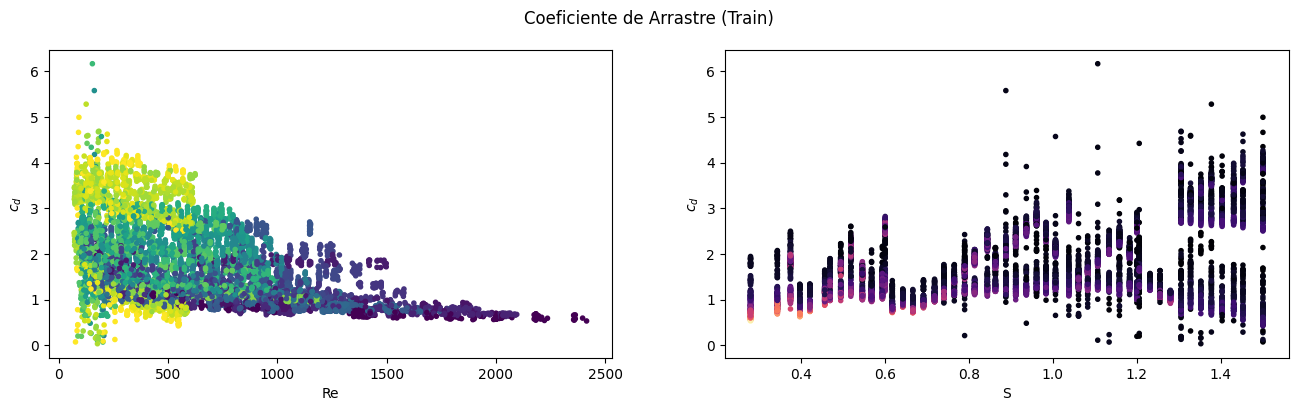

In [104]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4))

ax[0].scatter(x_train['Re'], y_train, marker='.', c=x_train['S'])
ax[0].set_xlabel('Re')
ax[0].set_ylabel(r'$c_d$')

ax[1].scatter(x_train['S'], y_train, marker='.', c=x_train['Re'], cmap='magma')
ax[1].set_xlabel('S')
ax[1].set_ylabel(r'$c_d$')

fig.suptitle('Coeficiente de Arrastre (Train)')
plt.show()

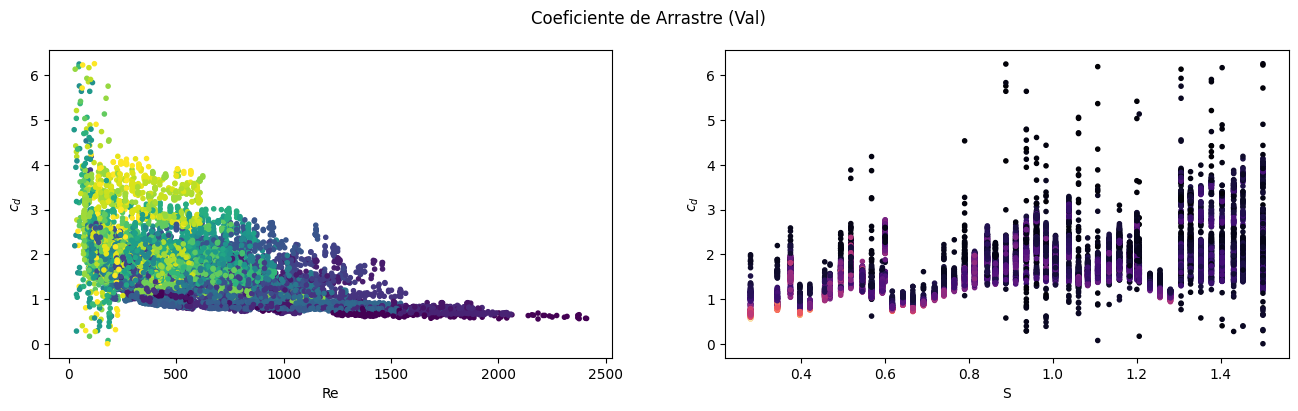

In [105]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4))

ax[0].scatter(x_val['Re'], y_val, marker='.', c=x_val['S'])
ax[0].set_xlabel('Re')
ax[0].set_ylabel(r'$c_d$')

ax[1].scatter(x_val['S'], y_val, marker='.', c=x_val['Re'], cmap='magma')
ax[1].set_xlabel('S')
ax[1].set_ylabel(r'$c_d$')

fig.suptitle('Coeficiente de Arrastre (Val)')
plt.show()

In [106]:
print(len(np.unique(x_train['S'])))

50


### Evolución Grámatica (sin segmentación)

In [107]:
from time import time
from tqdm import tqdm
from pysr import PySRRegressor

x_train.rename(columns={'S': 'Se'}, inplace=True)

In [108]:
model = PySRRegressor(
    niterations=200,
    binary_operators=["+","-","*" ,"/", "^"],
    unary_operators=[],
    population_size=50,
    populations=4,
    tournament_selection_n=3,
    verbosity=1,
    maxsize=20,
    parsimony=1e-2,
    constraints={'^':(-1,1)},
    complexity_of_variables=2,
    random_state=0,
    progress=True
)

t0 = time()
model.fit(x_train, y_train)
tf = time()
print(f"Tiempo de ejecución: {tf - t0} [s]")

C:\Users\matia\PycharmProjects\GE_Re_EL7037_2025\.venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
C:\Users\matia\PycharmProjects\GE_Re_EL7037_2025\.venv\Lib\site-packages\pysr\sr.py:2265: UserWarning: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (https://ai.damtp.cam.ac.uk/pysr/options/#batching). You should also reconsider if you need that many datapoints. Unless you have a large amount of noise (in which case you should smooth your dataset first), generally < 10,000 datapoints is enough to find a functional form with symbolic regression. More datapoints will lower the search speed.
  warnings.warn(
C:\Users\matia\PycharmProjects\GE_Re_EL7037_2025\.venv\Lib\site-packages\pysr\sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic 


Expressions evaluated per second: 2.970e+04
Progress: 26 / 800 total iterations (3.250%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.308e-01  0.000e+00  y = 1.7009
4           4.802e-01  9.089e-02  y = Se - -0.8024
6           4.769e-01  3.518e-03  y = 0.79482 + (Se ^ 1.1938)
9           4.692e-01  5.388e-03  y = ((Re ^ -0.34366) - -0.69533) + Se
11          4.691e-01  7.356e-05  y = (((Re - 1.6945) ^ -0.34366) - -0.69533) + Se
14          4.418e-01  2.002e-02  y = ((((Se ^ 0.85886) - -1.1326) + Re) * 0.99946) - Re
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expression

[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 6.520e+04
Progress: 779 / 800 total iterations (97.375%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.308e-01  0.000e+00  y = 1.7009
4           4.802e-01  9.089e-02  y = Se - -0.8024
6           4.767e-01  3.660e-03  y = (Se ^ 1.2079) + 0.8058
7           4.729e-01  8.125e-03  y = (Re ^ -0.034208) + Se
9           4.430e-01  3.261e-02  y = ((96.426 / Re) + 0.55811) + Se
11          4.411e-01  2.133e-03  y = ((129.49 / (Re + 38.101)) + Se) + 0.51692
13          4.411e-01  2.515e-05  y = ((129.49 / ((Re - -1.2561) + 38.101)) + Se) + 0.51692
14          4.405e-01  1.287e-03  y = (Se - (((-1.5252 + Re) * 1.0007) - Re)) * 0.84215
16          4.339e-01  7.633e-03  y = ((Se + 0.91418) + ((Se / (Re ^ -0.50084)) * -0.019886)...
                      

In [109]:
equations = model.equations_['equation']
equations = equations.apply(lambda x: x.replace('^', '**'))
print('=== TRAIN ===')
df_train = eval_equations(x_train, y_train, equations).sort_values(by='mse')
display(df_train)

print('\n=== VALIDATION ===')
x_val.rename(columns={'S': 'Se'}, inplace=True)
df_val = eval_equations(x_val, y_val, equations).sort_values(by='mse')
display(df_val)

=== TRAIN ===


,expresiones,mse
8,((Se + 0.9141782) + ((Se / (Re ** -0.50083816)...,0.433862
7,(Se - (((-1.5251601 + Re) * 1.0006578) - Re)) ...,0.440536
6,((129.48993 / ((Re - -1.2561272) + 38.10133)) ...,0.441103
5,((129.48993 / (Re + 38.10133)) + Se) + 0.5169155,0.441125
4,((96.42577 / Re) + 0.5581075) + Se,0.443011
3,(Re ** -0.034208477) + Se,0.472866
2,(Se ** 1.2078688) + 0.80580163,0.476724
1,Se - -0.8024,0.480226
0,1.7009448,inf



=== VALIDATION ===


,expresiones,mse
6,((129.48993 / ((Re - -1.2561272) + 38.10133)) ...,0.270471
5,((129.48993 / (Re + 38.10133)) + Se) + 0.5169155,0.270602
4,((96.42577 / Re) + 0.5581075) + Se,0.271917
8,((Se + 0.9141782) + ((Se / (Re ** -0.50083816)...,0.273838
7,(Se - (((-1.5251601 + Re) * 1.0006578) - Re)) ...,0.275805
3,(Re ** -0.034208477) + Se,0.305390
1,Se - -0.8024,0.312428
2,(Se ** 1.2078688) + 0.80580163,0.315795
0,1.7009448,inf


In [110]:
expr = sp.sympify(
    df_val['expresiones'].iloc[0]
).evalf(4)
expr

Se + 0.5169 + 129.5/(Re + 39.36)

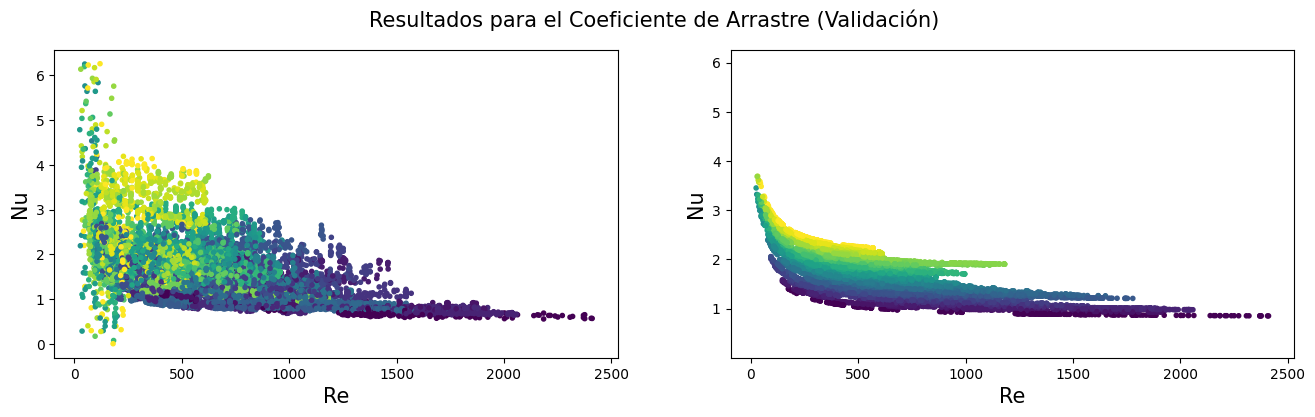

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4))

x = x_val
y = y_val

ax[0].scatter(x['Re'], y, marker='.', c=x['S'])
ax[0].set_xlabel('Re', fontsize=15)
ax[0].set_ylabel('Nu', fontsize=15)

y_pred = x['S'] + 0.5169 + 129.5 / (x['Re'] + 39.36)
ax[1].scatter(x['Re'], y_pred, marker='.', c=x['S'])
ax[1].set_xlabel('Re', fontsize=15)
ax[1].set_ylabel('Nu', fontsize=15)
ax[1].set_ylim([y.min(), y.max()])

fig.suptitle('Resultados para el Coeficiente de Arrastre (Validación)', fontsize=15)
plt.show()

In [111]:
x_test = pd.read_csv(r'.\DATA_LIB_Degradation\df_cdrag_test_des.txt')
y_true = x_test['cdrag']
x_test = x_test.drop('cdrag', axis=1)
print('x_test:')
display(x_train.head())
print('y_test:', y_true.to_numpy()[: 5])

f = sp.lambdify(sp.symbols('Re SoH Se'), expr, 'numpy')
y_pred = f(x_test['Re'].to_numpy(),
           x_test['SoH'].to_numpy(),
           x_test['S'].to_numpy())
print('y_pred =', y_pred[: 5])
print('n_pred =', len(y_pred), '/ n_true =', len(y_true))
print()

results = get_general_metrics(y_pred, y_true)
for key, value in results.items():
    print(key, '=', value[0], '+/-', value[1])

x_test:


,Se,Re,SoH
0,0.280625,212.041256,0.6363
1,0.280625,212.041256,1.0000
2,0.280625,197.894331,1.0000
3,0.344410,188.969448,0.6363
4,0.344410,188.969448,1.0000


y_test: [1.84063062 1.80419647 1.83289982 1.84955957 1.93785371]
y_pred = [1.31530254 1.31530254 1.34891591 1.37223919 1.38291351]
n_pred = 15639 / n_true = 15639

RMSE = 0.53 +/- 0.34
MAE = 0.4 +/- 0.34
SMAPE = 24.05 +/- 17.52


## Factor de Fricción

### Base de datos y exploración

In [16]:
x_train = pd.read_csv(r'.\DATA_LIB_Degradation\df_ff_train_des.txt')
y_train = x_train['frictionFactor']
x_train = x_train.drop('frictionFactor', axis=1)
print('x_train:')
display(x_train.head())
print('y_train:', y_train.to_numpy()[: 5])

x_train:


,S,Re,SoH
0,0.280625,212.041256,0.6363
1,0.280625,212.041256,1.0000
2,0.280625,197.894331,1.0000
3,0.344410,188.969448,0.6363
4,0.344410,188.969448,1.0000


y_train: [3.01555351 2.9419802  3.26051676 2.69129088 2.40581715]


In [17]:
x_min, x_max = x_train.min(), x_train.max()
xn_train = (x_train - x_min) / (x_max - x_min)
xn_train.head()
x_val = pd.read_csv(r'.\DATA_LIB_Degradation\df_ff_val_des.txt')
y_val = x_val['frictionFactor']
x_val = x_val.drop('frictionFactor', axis=1)
xn_val = (x_val - x_min) / (x_max - x_min)
xn_val.head()

,S,Re,SoH
0,0.753974,0.229825,1.000000
1,0.753974,0.223500,1.000000
2,0.753974,0.214392,1.000000
3,0.753974,0.209950,1.000000
4,0.621218,0.287809,0.666544


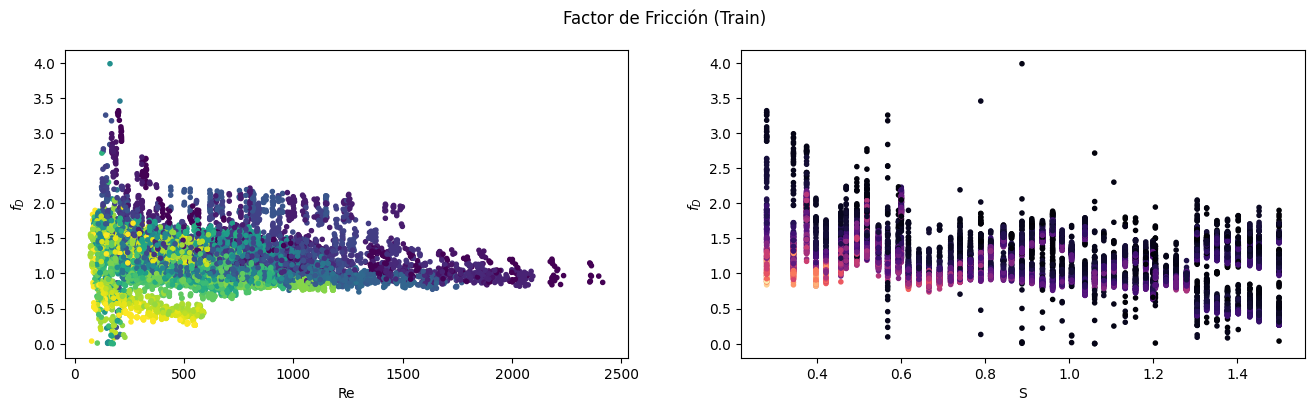

In [114]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4))

ax[0].scatter(x_train['Re'], y_train, marker='.', c=x_train['S'])
ax[0].set_xlabel('Re')
ax[0].set_ylabel(r'$f_D$')

ax[1].scatter(x_train['S'], y_train, marker='.', c=x_train['Re'], cmap='magma')
ax[1].set_xlabel('S')
ax[1].set_ylabel(r'$f_D$')

fig.suptitle('Factor de Fricción (Train)')
plt.show()

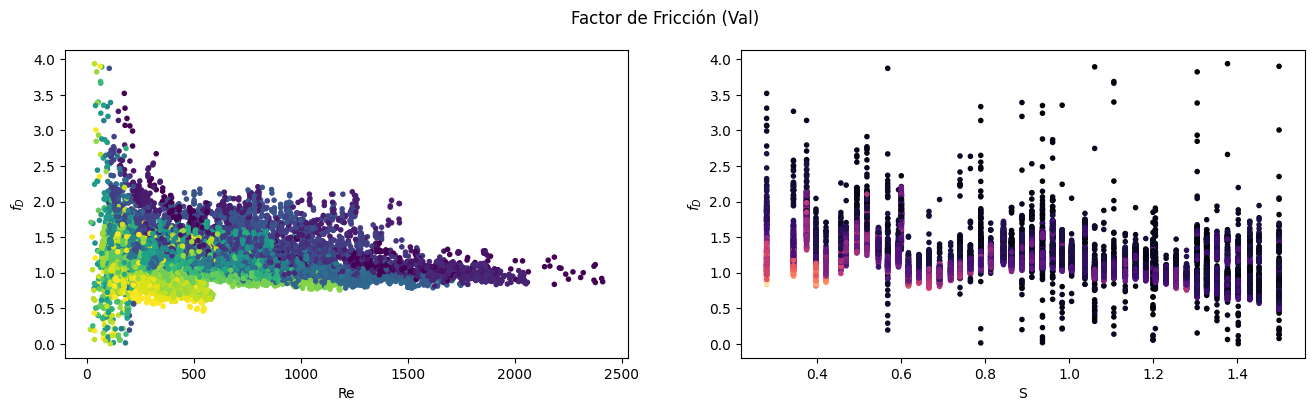

In [115]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4))

ax[0].scatter(x_val['Re'], y_val, marker='.', c=x_val['S'])
ax[0].set_xlabel('Re')
ax[0].set_ylabel(r'$f_D$')

ax[1].scatter(x_val['S'], y_val, marker='.', c=x_val['Re'], cmap='magma')
ax[1].set_xlabel('S')
ax[1].set_ylabel(r'$f_D$')

fig.suptitle('Factor de Fricción (Val)')
plt.show()

In [116]:
print(len(np.unique(x_train['S'])))

50


### Evolución Grámatica (sin segmentación)

In [117]:
from time import time
from tqdm import tqdm
from pysr import PySRRegressor

x_train.rename(columns={'S': 'Se'}, inplace=True)

In [118]:
model = PySRRegressor(
    niterations=200,
    binary_operators=["+","-","*" ,"/", "^"],
    unary_operators=[],
    population_size=50,
    populations=4,
    tournament_selection_n=3,
    verbosity=1,
    maxsize=20,
    parsimony=1e-2,
    constraints={'^':(-1,1)},
    complexity_of_variables=2,
    random_state=0,
    progress=True
)

t0 = time()
model.fit(x_train, y_train)
tf = time()
print(f"Tiempo de ejecución: {tf - t0} [s]")

C:\Users\matia\PycharmProjects\GE_Re_EL7037_2025\.venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
C:\Users\matia\PycharmProjects\GE_Re_EL7037_2025\.venv\Lib\site-packages\pysr\sr.py:2265: UserWarning: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (https://ai.damtp.cam.ac.uk/pysr/options/#batching). You should also reconsider if you need that many datapoints. Unless you have a large amount of noise (in which case you should smooth your dataset first), generally < 10,000 datapoints is enough to find a functional form with symbolic regression. More datapoints will lower the search speed.
  warnings.warn(
C:\Users\matia\PycharmProjects\GE_Re_EL7037_2025\.venv\Lib\site-packages\pysr\sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic 


Expressions evaluated per second: 1.800e+04
Progress: 14 / 800 total iterations (1.750%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.273e-01  0.000e+00  y = 1.2114
6           1.148e-01  2.080e-02  y = 1.4783 - (0.27384 * Se)
10          1.131e-01  3.597e-03  y = (0.86212 / ((Se + 0.454) ^ 0.36434)) / 0.64972
12          1.131e-01  2.327e-04  y = (((1.0154 / (Se ^ -0.47212)) ^ -0.47212) / 1.0161) * 1...
                                      .1824
15          1.121e-01  2.855e-03  y = (Re ^ -0.066444) - ((-0.066444 / 0.27384) / (0.44516 *...
                                       (Se ^ 0.23761)))
20          1.095e-01  4.779e-03  y = (Re ^ -0.066444) + ((0.066285 - (-0.066444 - ((Re ^ -0...
                                      .18451) * (0.95892 * 0.76967)))) / Se)
─────────

[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 2.180e+04
Progress: 711 / 800 total iterations (88.875%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.273e-01  0.000e+00  y = 1.2114
6           1.131e-01  2.377e-02  y = (Se ^ -0.22292) * 1.1554
8           1.131e-01  1.550e-06  y = ((Se + 0.28394) ^ -0.3961) + 0.25147
9           9.982e-02  1.247e-01  y = ((Re ^ -0.22945) / Se) + 0.89669
11          9.729e-02  1.284e-02  y = ((Re ^ -0.27972) / (0.4882 * Se)) + 0.72025
13          9.052e-02  3.606e-02  y = (((0.22743 - (Re ^ -0.16454)) * -1.9841) / Se) + 0.877...
                                      47
17          8.831e-02  6.194e-03  y = (((((0.25606 - (Re ^ -0.1598)) * 1.499) / Se) * -1.859...
                                      9) + 0.82416) - 0.025705
────────────────────────────────

In [119]:
equations = model.equations_['equation']
equations = equations.apply(lambda x: x.replace('^', '**'))
print('=== TRAIN ===')
df_train = eval_equations(x_train, y_train, equations).sort_values(by='mse')
display(df_train)

print('\n=== VALIDATION ===')
x_val.rename(columns={'S': 'Se'}, inplace=True)
df_val = eval_equations(x_val, y_val, equations).sort_values(by='mse')
display(df_val)

=== TRAIN ===


,expresiones,mse
8,((0.25606337 - (Re ** -0.15980455)) * ((1.4989...,0.088217
7,(((((0.25606337 - (Re ** -0.15980455)) * 1.498...,0.088307
6,(((0.22743377 - ((Re + -0.94934) ** -0.1645441...,0.090494
5,(((0.22743377 - (Re ** -0.16454414)) * -1.9841...,0.090523
4,((Re ** -0.2797188) / (0.488201 * Se)) + 0.720...,0.097292
3,((Re ** -0.22945052) / Se) + 0.8966898,0.099823
2,((Se ** -0.18913063) * 1.3794578) + -0.22375883,0.113073
1,(Se ** -0.22292398) * 1.1553878,0.113078
0,1.211369,inf



=== VALIDATION ===


,expresiones,mse
7,(((((0.25606337 - (Re ** -0.15980455)) * 1.498...,0.064775
8,((0.25606337 - (Re ** -0.15980455)) * ((1.4989...,0.065148
6,(((0.22743377 - ((Re + -0.94934) ** -0.1645441...,0.066693
5,(((0.22743377 - (Re ** -0.16454414)) * -1.9841...,0.066697
4,((Re ** -0.2797188) / (0.488201 * Se)) + 0.720...,0.071370
3,((Re ** -0.22945052) / Se) + 0.8966898,0.074511
2,((Se ** -0.18913063) * 1.3794578) + -0.22375883,0.085465
1,(Se ** -0.22292398) * 1.1553878,0.085530
0,1.211369,inf


In [120]:
expr = sp.sympify(
    df_val['expresiones'].iloc[0]
).evalf(4)
expr

0.7985 - 1.86*(0.3838 - 1.499/Re**0.1598)/Se

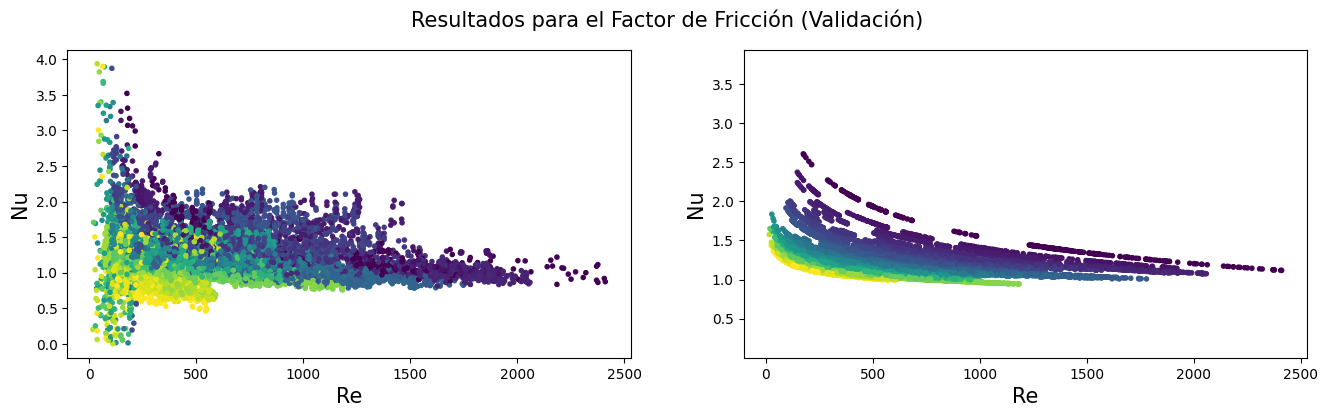

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4))

x = x_val
y = y_val

ax[0].scatter(x['Re'], y, marker='.', c=x['S'])
ax[0].set_xlabel('Re', fontsize=15)
ax[0].set_ylabel('Nu', fontsize=15)

y_pred = 0.7985 - (1.86 * (0.3838 - 1.499 / x['Re'] ** 0.1598)) / x['S']
ax[1].scatter(x['Re'], y_pred, marker='.', c=x['S'])
ax[1].set_xlabel('Re', fontsize=15)
ax[1].set_ylabel('Nu', fontsize=15)
ax[1].set_ylim([y.min(), y.max()])

fig.suptitle('Resultados para el Factor de Fricción (Validación)', fontsize=15)
plt.show()

In [121]:
x_test = pd.read_csv(r'.\DATA_LIB_Degradation\df_ff_test_des.txt')
y_true = x_test['frictionFactor']
x_test = x_test.drop('frictionFactor', axis=1)
print('x_test:')
display(x_train.head())
print('y_test:', y_true.to_numpy()[: 5])

f = sp.lambdify(sp.symbols('Re SoH Se'), expr, 'numpy')
y_pred = f(x_test['Re'].to_numpy(),
           x_test['SoH'].to_numpy(),
           x_test['S'].to_numpy())
print('y_pred =', y_pred[: 5])
print('n_pred =', len(y_pred), '/ n_true =', len(y_true))
print()

results = get_general_metrics(y_pred, y_true)
for key, value in results.items():
    print(key, '=', value[0], '+/-', value[1])

x_test:


,Se,Re,SoH
0,0.280625,212.041256,0.6363
1,0.280625,212.041256,1.0000
2,0.280625,197.894331,1.0000
3,0.344410,188.969448,0.6363
4,0.344410,188.969448,1.0000


y_test: [3.0442087  2.99253505 3.09981516 3.05552637 3.26630343]
y_pred = [2.47988721 2.47988721 2.53089754 2.56518877 2.58060574]
n_pred = 15626 / n_true = 15626

RMSE = 0.25 +/- 0.17
MAE = 0.18 +/- 0.17
SMAPE = 15.52 +/- 14.06
